In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sedona.stats.clustering.dbscan import dbscan
import pyspark.sql.functions as f

In [2]:
additional_packages = [
    'org.apache.sedona:sedona-spark-3.5_2.12:1.7.2',
    'org.datasyslab:geotools-wrapper:1.7.2-28.5',
]

config_params = {
    "spark.jars.packages": ",".join(additional_packages),
    "spark.hadoop.fs.s3a.aws.credentials.provider": "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider"
}

if os.environ.get("SEDONA_COPY_MINIO") == "true":
    config_params = {
        **config_params,
        **{
            "spark.hadoop.fs.s3a.access.key": "sedona",
            "spark.hadoop.fs.s3a.secret.key": "sedona_password",
            "spark.hadoop.fs.s3a.endpoint": "http://minio:9000",
            "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
            "spark.hadoop.fs.s3a.path.style.access": "true",
            "spark.driver.memory": "2G",
            "spark.executor.memory": "2G"
        }
    }

bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

for key, value in config_params.items():
    config = config.config(key, value)

sedona = SedonaContext.create(config.getOrCreate())
sedona.sparkContext.setLogLevel("ERROR")

sedona.sparkContext.setCheckpointDir("checkpoint")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ab50b82d-f014-4b29-896b-a6794f621ddd;1.0
	confs: [default]
	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.2 in central
	found org.apache.sedona#sedona-common;1.7.2 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-

# Density Points location

In [14]:
density_points = pd.read_csv("../source_data/density_points/density_points.csv").reset_index()

Text(0.5, 1.0, 'Point Locations')

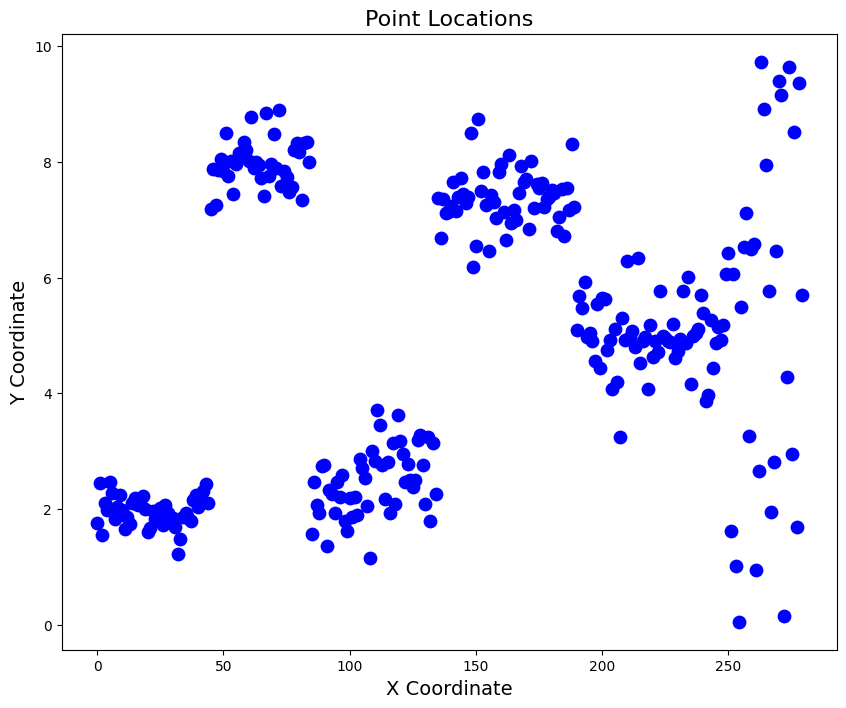

In [15]:
plt.figure(figsize=(10, 8))

plt.scatter(
    np.array(density_points)[:, 0], 
    np.array(density_points)[:, 1],
    s=80, 
    color="blue"
)
plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.title('Point Locations', fontsize=16)

## DBScan parameters

In [16]:
epsilon = 0.5
min_pts = 10

## Example point Vizualization

In [21]:
index = 10

x, y = density_points[density_points["index"] == index][["x", "y"]].values.tolist()[0]

spatial_df = sedona.createDataFrame(density_points).\
    selectExpr("index", "ST_Point(x, y) AS geom")

spatial_df.createOrReplaceTempView("points")

example_point = spatial_df.\
    where(f"index == {index}").\
    selectExpr("index", f"ST_Buffer(geom, {epsilon}) AS geom")

neighbors = example_point.alias("e").\
    join(spatial_df.alias("s"), f.expr("ST_Intersects(s.geom, e.geom)")).\
    selectExpr("s.index", "s.geom")

In [22]:
## example point is core point
neighbors.count() > min_pts

True

In [23]:
example = spatial_df.join(neighbors, "index", "leftanti").\
    where(f"index!={index}").\
    withColumn("type", f.lit("normal")).\
    withColumn("opacity", f.lit(0.5)).\
    unionAll(example_point.withColumn("type", f.lit("example_point_buffer")).withColumn("opacity", f.lit(0.5))).\
    unionAll(neighbors.withColumn("type", f.lit("neighbors")).withColumn("opacity", f.lit(0.5))).\
    unionAll(spatial_df.where(f"index={index}").withColumn("type", f.lit("example_point")).withColumn("opacity", f.lit(0.5)))

gdf = gpd.GeoDataFrame(example.toPandas(), geometry="geom")

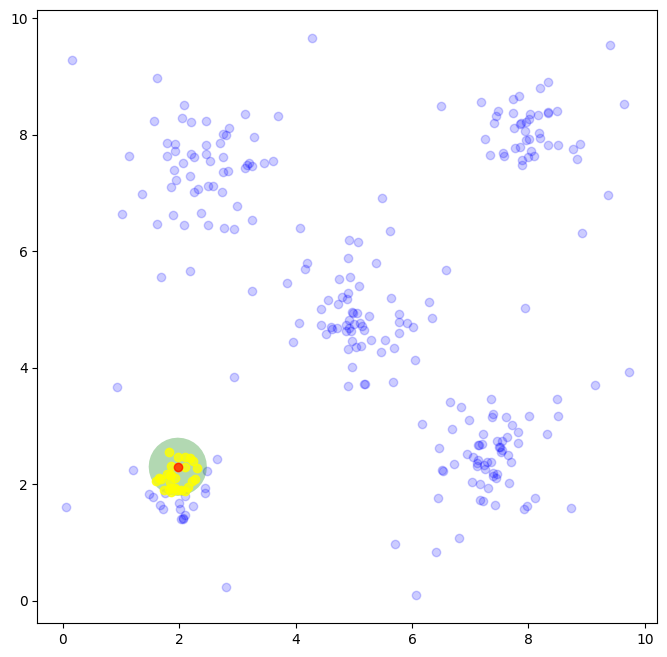

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

geom_types = {
    "normal": ["blue", 0.2],
    "example_point_buffer": ["green", 0.3],
    "neighbors": ["yellow", 0.8],
    "example_point": ["red", 0.7]
}

for geom_type, properties in geom_types.items():
    gdf[gdf["type"] == geom_type].plot(alpha=properties[1], ax=ax, color=properties[0])

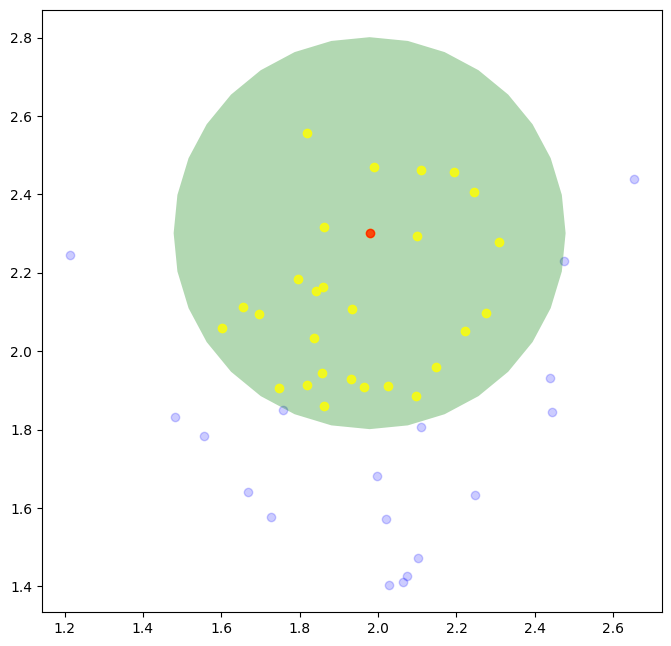

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))


for geom_type, properties in geom_types.items():
    gdf[
        (gdf["type"] == geom_type) &
        (gdf["geom"].centroid.x < x+1) &
        (gdf["geom"].centroid.y < y+1) &
        (gdf["geom"].centroid.y > y-1) &
        (gdf["geom"].centroid.x > x-1)
    ].plot(alpha=properties[1], ax=ax, color=properties[0])

## Sedona DBScan algorithm

In [26]:
sedona.table("points").printSchema()

root
 |-- index: long (nullable = true)
 |-- geom: geometry (nullable = true)



In [47]:
dbscan_df = sedona.sql(
    """
    SELECT
        index,
        geom AS geom,
        ST_DBSCAN(geom, 0.5, 10, False) AS scan
    FROM points
    """
)

result = dbscan_df.select("scan.*", "index", "geom")

In [ ]:
result.printSchema()

root
 |-- isCore: boolean (nullable = true)
 |-- cluster: long (nullable = true)
 |-- index: long (nullable = true)
 |-- geom: geometry (nullable = true)



In [52]:
result.cache().count()

+------+------------+-----+--------------------+
|isCore|     cluster|index|                geom|
+------+------------+-----+--------------------+
| false| 51539607552|  165|POINT (7.16618081...|
| false|  8589934594|  134|POINT (2.26290455...|
| false|249108103169|  239|POINT (5.70002406...|
| false|  8589934594|  119|POINT (3.61527021...|
| false|  8589934592|   32|POINT (1.21407646...|
| false| 51539607552|  172|POINT (8.00652102...|
| false|249108103169|  192|POINT (5.47358198...|
| false|           0|   45|POINT (7.18117234...|
| false|249108103169|  194|POINT (4.97873014...|
| false|  8589934594|  101|POINT (1.86896643...|
| false|           0|   61|POINT (8.77405451...|
| false|           0|   70|POINT (8.48848638...|
| false| 51539607552|  189|POINT (7.22158394...|
| false|           0|   47|POINT (7.25666284...|
| false|  8589934594|  112|POINT (3.45681001...|
| false| 51539607552|  171|POINT (6.84469655...|
| false|           0|   81|POINT (7.33253491...|
| false|249108103169

280

In [54]:
unique_labels = [el[0] for el in result.selectExpr("cluster").distinct().collect()]

points = result.\
    selectExpr("ST_X(geom) AS x", "ST_Y(geom) AS y", "cluster").\
    toPandas()

## Vizualize DBScan result

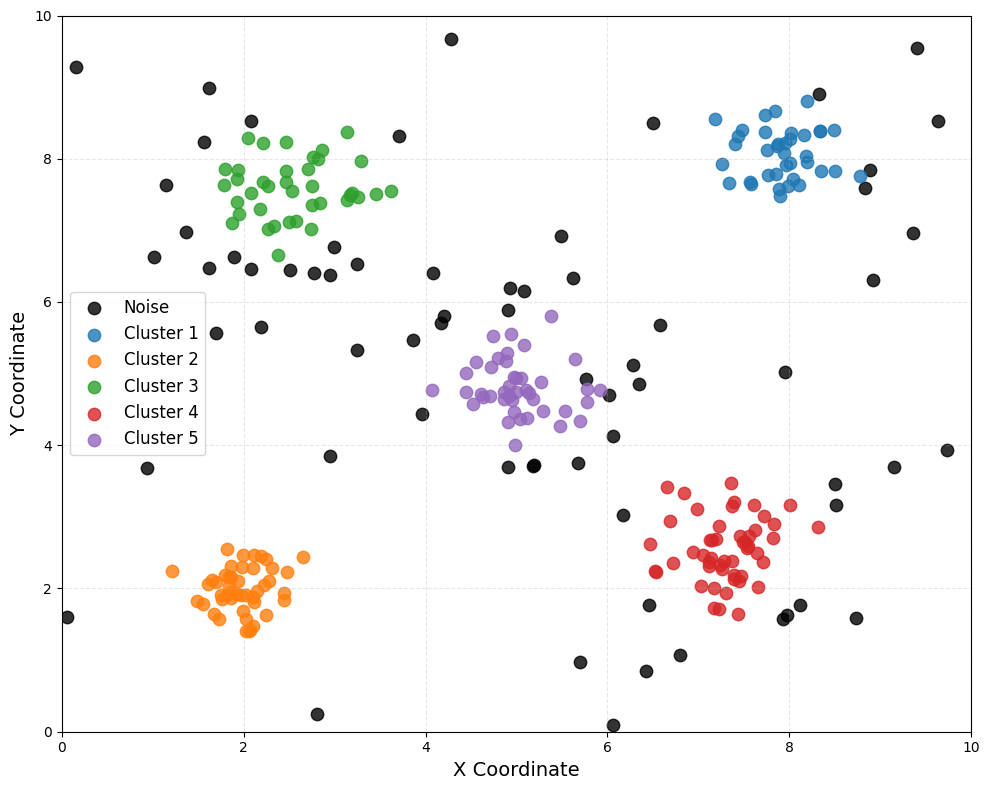

In [55]:
colors = ['black', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 8))
for index, (label, color) in enumerate(zip(sorted(unique_labels), colors)):
    plt.scatter(
        points[points["cluster"] == label]["x"],
        points[points["cluster"] == label]["y"],
        s=80,
        color=color,
        alpha=0.8,
        label=f'Cluster {index}' if label != -1 else 'Noise'
    )

plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()